# CNN Knot Detector - Counting Crossings

This notebook is the **thin orchestration layer** for training and evaluating our Vanilla and CNN models using our package modules in `knot_detector/`.  

<!-- It avoids redefining models/loops inline and instead imports from the package to guarantee parity across CLI, scripts, and notebooks. -->

**What this notebook does**
1. Sets up paths & config (seed, epochs, batch size, etc.).  
1. Prints dataset sanity info (class map, counts) and shows a small sample grid.  
<!-- 1. Runs a tiny **overfit** sanity check (optional).   -->
1. Trains for N epochs and evaluates accuracy.  
1. Saves a checkpoint and shows a confusion matrix.

> Tip: run this notebook from your repo's `notebooks/` folder. If imports fail, ensure the project root is on `sys.path` or install your package in editable mode: `pip install -e .`.


In [6]:
!pip install -r ../requirements.txt -q

## Imports & Project Path Wiring

In [58]:
# --- Imports & project path wiring ---
from pathlib import Path
import sys, os, random
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root (parent of this notebooks/ folder) is importable
PROJ_ROOT = Path.cwd().parent
if str(PROJ_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJ_ROOT))

# Import our package modules
from knot_detector.data.dataset import get_dataloaders
from knot_detector.train import train_model
from knot_detector.eval import evaluate


## Config

In [59]:
# --- Config ---
SEED = 1337
EPOCHS = 1
BATCH_SIZE = 32
# IMG_SIZE = 480
IMG_SIZE = 512  # Use 512 for the original model; adapt if you add an adaptive pool

LR = 1e-3
OVERFIT_BATCHES = None     # None to skip, e.g. 2 to sanity check
SAVE_CKPT = ""             # e.g., "../outputs/knotcnn.ckpt"

# Primary (relative) data root expected by the repo
DATA_ROOT = Path("../data/raw/knot-crossings@main")

print("Project root:", PROJ_ROOT)
print("Data root:", DATA_ROOT.resolve())


Project root: /Users/annedranowski/HQ/🚀 Projects/Knot Detector
Data root: /Users/annedranowski/HQ/🚀 Projects/Knot Detector/data/raw/knot-crossings@main


## Data & transforms 

In [60]:
# original model (no adaptive pool) → set IMG_SIZE = 512 in your config

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path

# use DATA_ROOT and IMG_SIZE from your config cell
ABS_FALLBACK = Path("/Users/annedranowski/HQ/🚀 Projects/Knot Detector/data/raw/knot-crossings@main")
if not DATA_ROOT.exists() and ABS_FALLBACK.exists():
    DATA_ROOT = ABS_FALLBACK

# model expects 1 channel; final FC assumes 12×12 → need 512×512 input
assert IMG_SIZE == 512, "Set IMG_SIZE=512 in the config for the non-adaptive model."

tfm = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(DATA_ROOT / "train", transform=tfm)
test_ds  = datasets.ImageFolder(DATA_ROOT / "test",  transform=tfm)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("train:", len(train_ds), "test:", len(test_ds))
print("classes:", train_ds.classes)


train: 9051 test: 49
classes: ['0', '10', '3', '4', '5', '6', '7', '8', '9']


## Seeding & Device

In [61]:
# --- Seeding helper (matches package behavior) ---
import torch

def seed_all(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_all(SEED)
device = ("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
device


'mps'

## Build dataloaders & print sanity info

In [62]:
# --- Build dataloaders & print sanity info ---
train_dl, test_dl = get_dataloaders(DATA_ROOT, img_size=IMG_SIZE, batch_size=BATCH_SIZE)

classes = train_dl.dataset.classes
print("Classes:", classes)
print("Num classes:", len(classes))
print("Train images:", len(train_dl.dataset))
print("Test  images:", len(test_dl.dataset))


Classes: ['0', '10', '3', '4', '5', '6', '7', '8', '9']
Num classes: 9
Train images: 9051
Test  images: 49


[warn] Train/Test class folders differ. Aligning by creating empty missing dirs is recommended.
train: ['0', '10', '3', '4', '5', '6', '7', '8', '9'] 
 test: ['0', '10', '11', '3', '4', '5', '6', '7', '8', '9']


## Sample grid (visual sanity)

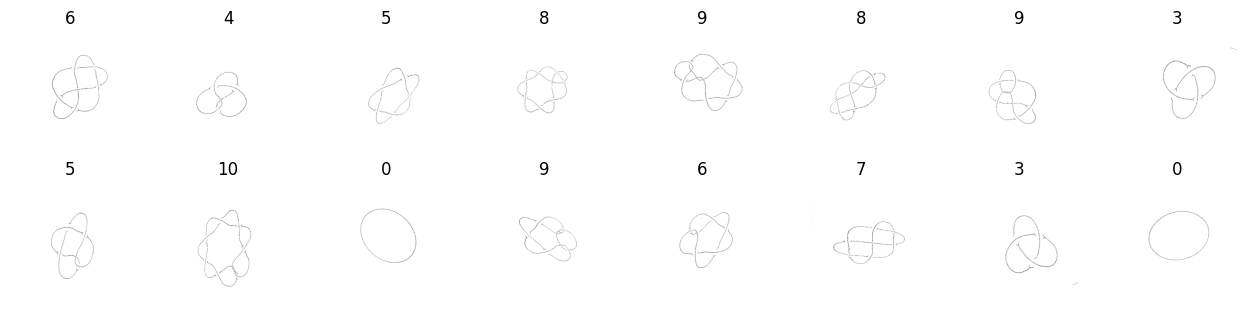

In [63]:
# --- Show a small sample grid from the training set ---
# Note: avoid seaborn; matplotlib only.
import math
from itertools import islice

n = 16
it = iter(train_dl)
xb, yb = next(it)
# If batch smaller than n, just use what's available
k = min(n, xb.size(0))
cols = 8
rows = math.ceil(k / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*1.6, rows*1.6))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i in range(k):
    img = xb[i].permute(1,2,0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(str(classes[yb[i].item()]))
    axes[i].axis("off")
for j in range(k, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()


## Overfit sanity

Flip OVERFIT_BATCHES=2 in the config to run this. You should see train loss → ~0 and accuracy → ~100% on those two batches. It’s the quickest end-to-end check that your packaged model/loop matches the notebook behavior.

In [20]:
# --- Overfit a couple of batches (optional) ---
if OVERFIT_BATCHES is not None:
    _ = train_model(
        DATA_ROOT,
        num_epochs=20,
        lr=LR,
        batch_size=BATCH_SIZE
    )
    print("Overfit sanity done.")
else:
    print("Skipping overfit sanity (set OVERFIT_BATCHES=2 to enable).")


Skipping overfit sanity (set OVERFIT_BATCHES=2 to enable).


TODO: Create validation test before tuning

```
from torch.utils.data import random_split

full_train = datasets.ImageFolder(root=cfg.TRAIN_DIR, transform=train_tfms)
n_val = int(0.1 * len(full_train))
n_train = len(full_train) - n_val
train_data, val_data = random_split(full_train, [n_train, n_val])
```

## Accuracy functions

In [26]:
def accuracy_fn(*, y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    # y_pred is already rounded (regression/binary) or argmaxed (multiclass) by the steps above
    return (y_pred.eq(y_true).float().mean().item()) * 100.0


## Train/Test Loops

In [ ]:
# # knot_detector/training/loops.py
# from __future__ import annotations
# from typing import Callable, Tuple, List
# import torch

# Tensor = torch.Tensor

# def _maybe_squeeze_logits(y_pred: Tensor) -> Tensor:
#     # If model returns shape [B,1], make it [B]
#     if y_pred.ndim == 2 and y_pred.size(-1) == 1:
#         return y_pred.squeeze(1)
#     return y_pred

# @torch.no_grad()
# def test_step(
#     data_loader: torch.utils.data.DataLoader,
#     model: torch.nn.Module,
#     loss_fn: torch.nn.Module,
#     accuracy_fn: Callable[..., float],
#     device: torch.device,
# ) -> Tuple[List[float], List[float], float, float]:
#     """
#     Runs one evaluation epoch.
#     Returns: (y_pred_list, y_true_list, avg_loss, avg_acc)
#     """
#     model.eval()
#     test_loss, test_acc = 0.0, 0.0
#     y_pred_list: List[float] = []
#     y_true_list: List[float] = []

#     for X, y in data_loader:
#         X, y = X.to(device), y.to(device)

#         logits = model(X)
#         logits = _maybe_squeeze_logits(logits)

#         # Collect rounded preds to mirror the notebook behavior
#         y_pred_list.extend([round(v) for v in logits.detach().cpu().tolist()])
#         y_true_list.extend([round(v) for v in y.detach().cpu().tolist()])

#         test_loss += loss_fn(logits, y.to(torch.float32)).item()
#         test_acc  += accuracy_fn(y_true=y, y_pred=logits.round())

#     n_batches = max(1, len(data_loader))
#     test_loss /= n_batches
#     test_acc  /= n_batches
#     return y_pred_list, y_true_list, test_loss, test_acc


# def train_step(
#     model: torch.nn.Module,
#     data_loader: torch.utils.data.DataLoader,
#     loss_fn: torch.nn.Module,
#     optimizer: torch.optim.Optimizer,
#     accuracy_fn: Callable[..., float],
#     device: torch.device,
# ) -> Tuple[List[float], List[float], float, float]:
#     """
#     Runs one training epoch.
#     Returns: (y_pred_list, y_true_list, avg_loss, avg_acc)
#     """
#     model.train()
#     train_loss, train_acc = 0.0, 0.0
#     y_pred_list: List[float] = []
#     y_true_list: List[float] = []

#     for X, y in data_loader:
#         X, y = X.to(device), y.to(device)

#         # 1) forward
#         logits = model(X)
#         logits = _maybe_squeeze_logits(logits)

#         # Collect preds/targets like your notebook
#         y_pred_list.extend([round(v) for v in logits.detach().cpu().tolist()])
#         y_true_list.extend([round(v) for v in y.detach().cpu().tolist()])

#         # 2) loss
#         loss = loss_fn(logits, y.to(torch.float32))
#         train_loss += loss.item()
#         train_acc  += accuracy_fn(y_true=y, y_pred=logits.round())

#         # 3–5) optimize
#         optimizer.zero_grad(set_to_none=True)
#         loss.backward()
#         optimizer.step()

#     n_batches = max(1, len(data_loader))
#     train_loss /= n_batches
#     train_acc  /= n_batches
#     return y_pred_list, y_true_list, train_loss, train_acc


In [64]:
# ===== notebook cell: compact train/test steps (nb-local) =====
from typing import Callable, List, Tuple
import torch

Tensor = torch.Tensor

def _maybe_squeeze_last(y: Tensor) -> Tensor:
    # if logits are [B, 1] -> [B]; leave [B, C] untouched
    return y.squeeze(1) if (y.ndim == 2 and y.size(-1) == 1) else y

def _is_multiclass(logits: Tensor) -> bool:
    return logits.ndim == 2 and logits.size(-1) > 1

def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn: Callable[..., float],
               device: torch.device) -> Tuple[List[int], List[int], float, float]:
    model.train()
    train_loss, train_acc = 0.0, 0.0
    y_pred_list: List[int] = []
    y_true_list: List[int] = []

    for X, y in data_loader:
        X, y = X.to(device), y.to(device)

        # forward
        logits = model(X)
        logits = _maybe_squeeze_last(logits)

        # choose prediction/target format based on head type
        if _is_multiclass(logits):
            # e.g., CrossEntropyLoss with C>1 classes
            preds = logits.argmax(dim=1)
            loss  = loss_fn(logits, y.long())
            y_pred_list += preds.detach().cpu().tolist()
            y_true_list += y.long().detach().cpu().tolist()
            acc_add = accuracy_fn(y_true=y, y_pred=preds)
        else:
            # regression/binary-with-logits style
            preds = logits.round()
            loss  = loss_fn(logits, y.to(torch.float32))
            y_pred_list += [int(round(v)) for v in logits.detach().cpu().tolist()]
            y_true_list += [int(round(v)) for v in y.detach().cpu().tolist()]
            acc_add = accuracy_fn(y_true=y, y_pred=preds)

        # optimize
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc  += acc_add

    n_batches = max(1, len(data_loader))
    train_loss /= n_batches
    train_acc  /= n_batches
    print(f"\nTrain loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
    return y_pred_list, y_true_list, train_loss, train_acc


@torch.no_grad()
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn: Callable[..., float],
              device: torch.device) -> Tuple[List[int], List[int], float, float]:
    model.eval()
    test_loss, test_acc = 0.0, 0.0
    y_pred_list: List[int] = []
    y_true_list: List[int] = []

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            logits = _maybe_squeeze_last(logits)

            if _is_multiclass(logits):
                preds = logits.argmax(dim=1)
                loss  = loss_fn(logits, y.long())
                y_pred_list += preds.detach().cpu().tolist()
                y_true_list += y.long().detach().cpu().tolist()
                acc_add = accuracy_fn(y_true=y, y_pred=preds)
            else:
                preds = logits.round()
                loss  = loss_fn(logits, y.to(torch.float32))
                y_pred_list += [int(round(v)) for v in logits.detach().cpu().tolist()]
                y_true_list += [int(round(v)) for v in y.detach().cpu().tolist()]
                acc_add = accuracy_fn(y_true=y, y_pred=preds)

            test_loss += loss.item()
            test_acc  += acc_add

    n_batches = max(1, len(data_loader))
    test_loss /= n_batches
    test_acc  /= n_batches
    print(f"\nTest loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")
    return y_pred_list, y_true_list, test_loss, test_acc

## Define models

In [37]:
# CNN
import torch
from torch import nn

class KnotCNN(nn.Module):
    def __init__(self, output_shape: int):
        super().__init__()

        self.conv_1 = nn.Sequential(
          nn.Conv2d(1, 4, kernel_size=11, stride=1, dilation=2, padding=0),
          nn.BatchNorm2d(4),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2),

          nn.Conv2d(4, 16, kernel_size=5, stride=1, dilation=2, padding=0),
          nn.BatchNorm2d(16),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2),

          nn.Conv2d(16, 64, kernel_size=3, stride=1, dilation=2, padding=0),
          nn.BatchNorm2d(64),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2),

          nn.Conv2d(64, 256, kernel_size=3, stride=1, dilation=2, padding=0),
          nn.BatchNorm2d(256),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2),

          nn.Conv2d(256, 361, kernel_size=3, stride=1, padding=0),
          nn.BatchNorm2d(361),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(361*(12)**2),
            nn.Dropout(p=0.7),
            nn.Linear(in_features=361*(12)**2, out_features=4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(),
            nn.Dropout(p=0.7),
            nn.Linear(in_features=4096, out_features=4096),
            nn.ReLU(),
            nn.Linear(4096, output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_1(x)
        x = self.classifier(x)
        return x


In [ ]:
# Agnostic version
# Make the model input-size agnostic (recommended)
# If you’d like to keep using 480×480 (or any size) from earlier, add a tiny adaptive pool so the conv stack always lands on 12×12 before the classifier. That way you can keep your get_dataloaders(..., img_size=480) flow.

In [ ]:
# If you already have KnotCNN in your package, reuse it:
# from knot_detector.models import KnotCNN

# IMPORTANT: set num_classes=1 to match your scalar output + .squeeze(1) + regression loss
model = KnotCNN(num_classes=1).to(device)

# Your training assumed regression-style loss against integer class index
loss_fn  = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.__class__.__name__, sum(p.numel() for p in model.parameters())


('KnotCNN', 118059009)

## Eval model

In [28]:
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
    """Evaluates a model on data_loader; returns dict of metrics."""
    loss, acc = 0.0, 0.0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X).squeeze(dim=1)  # scalar head
            loss += loss_fn(y_pred, y.to(torch.float32)).item()
            acc  += accuracy_fn(y_true=y, y_pred=y_pred.round())

    loss /= max(1, len(data_loader))
    acc  /= max(1, len(data_loader))
    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss,
        "model_acc": acc
    }


In [30]:
# Eval model exists
# results = eval_model(model, test_dl, loss_fn, accuracy_fn, device)
# results

## make a square grid from a 1D tensor

What this does: to_square_grid is your original idea (with a safer integer sqrt). to_nearest_square_grid is a forgiving variant that pads to the next square.

In [31]:
# --- Grid helpers (NB cell) ---
import math
import torch

def to_square_grid(t: torch.Tensor) -> torch.Tensor:
    """
    Reshape a 1D tensor whose length is a perfect square into [S, S].
    Raises if it's not a perfect square (so you notice early).
    """
    t = t.flatten().to(torch.float32)
    n = t.numel()
    s = math.isqrt(n)               # exact integer sqrt (no float rounding)
    if s * s != n:
        raise ValueError(f"Length {n} is not a perfect square; cannot reshape to SxS.")
    return t.unflatten(0, (s, s))   # same spirit as your code

def to_nearest_square_grid(t: torch.Tensor) -> torch.Tensor:
    """
    Convenience: pad with zeros up to next square and reshape.
    Useful when you *want* a plot even if n isn't a perfect square.
    """
    t = t.flatten().to(torch.float32)
    n = t.numel()
    s = math.ceil(math.sqrt(n))
    pad = s*s - n
    if pad:
        t = torch.nn.functional.pad(t, (0, pad))
    return t.unflatten(0, (s, s))


## Helpers

In [32]:
# --- Helpers (shaping/normalizing) ---
import math
import torch
import matplotlib.pyplot as plt
from typing import Optional, Tuple

def to_square_grid_unsafe(vec: torch.Tensor) -> torch.Tensor:
    """Reshape 1D vec to SxS where S^2 == len(vec); raises if not perfect square."""
    v = vec.flatten().to(torch.float32)
    n = v.numel()
    s = math.isqrt(n)
    if s*s != n:
        raise ValueError(f"Length {n} is not a perfect square.")
    return v.unflatten(0, (s, s))

def to_nearest_square_grid(vec: torch.Tensor) -> torch.Tensor:
    """Pad 1D vec with zeros to next square and reshape to SxS."""
    v = vec.flatten().to(torch.float32)
    n = v.numel()
    s = math.ceil(math.sqrt(n))
    pad = s*s - n
    if pad:
        v = torch.nn.functional.pad(v, (0, pad))
    return v.unflatten(0, (s, s))

def normalize01(t: torch.Tensor) -> torch.Tensor:
    t = t.detach()
    mn, mx = t.min(), t.max()
    return (t - mn) / (mx - mn + 1e-8)

def show_heatmap(grid: torch.Tensor, title: str = ""):
    arr = grid.detach().cpu().numpy()
    fig = plt.figure(figsize=(4, 4))
    plt.imshow(arr, interpolation="nearest")
    if title: plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


## Weight maps for Linear/Conv

In [33]:
# --- Weight reductions (Linear/Conv) ---
import torch.nn as nn

def linear_weight_map(linear: nn.Linear, input_hw: Optional[Tuple[int,int]] = None,
                      reduce: str = "sum") -> torch.Tensor:
    """
    Reduce linear weight [out, in] over OUT -> [in], then reshape to HxW (or square).
    reduce: 'sum' or 'l2' (l2 = sqrt(mean(w^2) over out))
    """
    W = linear.weight.detach().cpu()  # [out, in]
    if reduce == "l2":
        v = W.pow(2).mean(dim=0).sqrt()
    else:
        v = W.sum(dim=0)
    if input_hw is not None:
        H, Wd = input_hw
        return v.reshape(-1)[:H*Wd].reshape(H, Wd)
    # fallback: best-effort square
    try:
        return to_square_grid_unsafe(v)
    except ValueError:
        return to_nearest_square_grid(v)

def conv_weight_map(conv: nn.Conv2d, reduce: str = "mean") -> torch.Tensor:
    """
    Reduce Conv2d weights [out,in,kh,kw] over channels to [kh,kw].
    """
    W = conv.weight.detach().cpu()  # [out, in, kh, kw]
    if reduce == "sum":
        k = W.sum(dim=(0, 1))
    else:
        k = W.mean(dim=(0, 1))
    return k  # [kh, kw]


## Weights plotters

In [34]:
# --- Replacement: plot_layer_weights ---
from typing import Iterable

def plot_layer_weights(layers: Iterable[nn.Module],
                       input_hw: Optional[Tuple[int,int]] = None,
                       conv_reduce: str = "mean",
                       lin_reduce: str  = "sum"):
    """
    For each layer: show an aggregated weight map.
    - Linear: reduce over out -> reshape to input_hw or square.
    - Conv2d: mean/sum over in/out -> kernel heatmap.
    """
    layers = list(layers)
    for i, layer in enumerate(layers):
        if isinstance(layer, nn.Linear):
            wm = linear_weight_map(layer, input_hw=input_hw, reduce=lin_reduce)
            show_heatmap(normalize01(wm), title=f"Linear[{i}] agg weight")
        elif isinstance(layer, nn.Conv2d):
            km = conv_weight_map(layer, reduce=conv_reduce)
            show_heatmap(normalize01(km), title=f"Conv2d[{i}] agg kernel")
        else:
            # Skip for non-visual layers
            continue


In [35]:
# --- Replacement: plot_layer_effects ---
def plot_layer_effects(layers: Iterable[nn.Module],
                       x: torch.Tensor,
                       device: torch.device,
                       input_hw: Optional[Tuple[int,int]] = None,
                       conv_reduce: str = "mean",
                       lin_reduce: str  = "sum"):
    """
    Per layer, show two images:
      1) An aggregated weight map (Conv: agg kernel; Linear: weight reshaped to spatial).
      2) The activation summary after applying the layer to x (Conv: mean over channels; Linear: output reshaped best-effort).
    """
    layers = list(layers)
    # ensure we have a single image tensor [C,H,W]
    if x.ndim == 4:  # [B,C,H,W]
        x = x[0]
    assert x.ndim == 3, f"Expected [C,H,W], got {x.shape}"

    z = x.to(device).unsqueeze(0)  # [1,C,H,W] for convs
    H, Wd = x.shape[1], x.shape[2]

    for i, layer in enumerate(layers):
        if isinstance(layer, (nn.BatchNorm2d, nn.BatchNorm1d)):
            # normalize only; keep flowing
            with torch.no_grad():
                if z.ndim == 2: z = z.unsqueeze(0)
                z = layer(z)
            continue
        if isinstance(layer, nn.Flatten):
            with torch.no_grad():
                z = layer(z)
            continue

        # 1) weight map
        if isinstance(layer, nn.Conv2d):
            wm = conv_weight_map(layer, reduce=conv_reduce)
            show_heatmap(normalize01(wm), title=f"Conv2d[{i}] agg kernel")
            # 2) activation
            with torch.no_grad():
                z = layer(z)
                act = z.detach().cpu().squeeze(0)  # [C,H,W]
                act_sum = act.mean(dim=0)          # [H,W]
            show_heatmap(normalize01(act_sum), title=f"Conv2d[{i}] activation (mean over channels)")

        elif isinstance(layer, nn.Linear):
            wm = linear_weight_map(layer, input_hw=input_hw or (H, Wd), reduce=lin_reduce)
            show_heatmap(normalize01(wm), title=f"Linear[{i}] agg weight (reshaped)")

            with torch.no_grad():
                # Expect z to be flat by now; if still [1,C,H,W], flatten it
                if z.ndim == 4:
                    z = torch.flatten(z, start_dim=1)
                z = layer(z)  # [1, out]
                out = z.detach().cpu().squeeze(0)
                # best-effort reshape for visualization
                try:
                    out_img = to_square_grid_unsafe(out)
                except ValueError:
                    out_img = to_nearest_square_grid(out)
            show_heatmap(normalize01(out_img), title=f"Linear[{i}] output reshaped")

        else:
            # other ops (ReLU/Pool/etc.)
            with torch.no_grad():
                if z.ndim == 4:
                    z = layer(z)
                else:
                    # if linear-like op after flatten
                    z = layer(z)


**Summary of improvements**

- ✅ Device-safe (no .cuda() hardcoding; works on CPU/MPS/CUDA).
- ✅ Robust reshaping (exact input_hw or pad to nearest square).
- ✅ Deterministic reductions (choose sum or l2 norms).
- ✅ No hidden globals; everything is explicit & reusable.
- ✅ Layer-aware: skips BN, handles Flatten, aggregates Conv sensibly.

In [25]:
# example driver loop in the notebook (keeps your old behavior, but explicit)
best_acc = -1.0
best_path = "../outputs/KnotCNN_best.pth"   # or None to disable
scheduler = None  # e.g., torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

for epoch in range(EPOCHS):
    _, _, tr_loss, tr_acc = train_step(model, train_dl, loss_fn, optimizer, accuracy_fn, device)
    _, _, te_loss, te_acc = test_step(test_dl, model, loss_fn, accuracy_fn, device)

    if scheduler is not None:
        # if it's ReduceLROnPlateau, step on validation loss
        try:
            scheduler.step(te_loss)
        except TypeError:
            scheduler.step()

    if best_path and te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), best_path)
        print(f"[ok] saved new best to {best_path} (acc={best_acc:.2f}%)")


NameError: name 'model' is not defined

## Train

In [ ]:
# knot_detector/train.py (excerpt)
from .training.loops import train_step, test_step

def train_model(..., scheduler=None, save_ckpt: str | None = None, ...):
    ...
    for epoch in range(num_epochs):
        ypred_tr, ytrue_tr, train_loss, train_acc = train_step(
            model, train_dl, criterion, optimizer, accuracy_fn, device
        )
        ypred_te, ytrue_te, val_loss, val_acc = test_step(
            val_dl, model, criterion, accuracy_fn, device
        )

        if scheduler is not None:
            # ReduceLROnPlateau expects a metric (use val_loss)
            try:
                scheduler.step(val_loss)
            except TypeError:
                scheduler.step()

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train {train_loss:.4f}/{train_acc:.2%} | "
              f"Val {val_loss:.4f}/{val_acc:.2%}")

        if save_ckpt:
            # implement your own "best so far" here if desired
            pass


In [5]:
# If in Colab, download data from GH or Google Drive
# TODO: provide data download cells
# E.g. If running in Google Colab
import sys
if 'google.colab' in sys.modules:
    # Install dependencies
    !pip install torch torchvision matplotlib pandas tqdm
    # (Optional) Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

In [ ]:
from collections import Counter
import os

# This will print how many images per class are in each split.
for split in ["train", "test"]: # "val", 
    c = Counter()
    for cls in os.listdir(f"../dataset/{split}"):
        # Skip hidden files like .DS_Store
        if cls.startswith('.'):
            continue
        c[cls] = len(os.listdir(f"../dataset/{split}/{cls}"))
    print(split, c)

train Counter({'9': 1029, '0': 1029, '7': 1029, '4': 1029, '3': 1029, '6': 1008, '10': 1008, '5': 1008, '8': 882})
test Counter({'9': 6, '7': 6, '6': 6, '10': 6, '8': 6, '5': 6, '4': 4, '3': 4, '0': 3, '11': 2})


In [4]:
# Data paths, hyperparameters (e.g., batch size, learning rate, num epochs)
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
train_data_path = '...'  # example
# etc
# Stay in the notebook: Parameter settings are high-level and may change between runs/experiments.

In [ ]:
# Custom Dataset class, image preprocessing, or DataLoader creation.
# TODO: Move class/function definitions to src/dataset.py.
# Keep only DataLoader instantiation (using imported class) in the notebook

In [ ]:
# Model class definition (VanillaNet, CNN, etc.)
# TODO: Move model class definitions to src/models.py
from models import KnotCNN
# model = KnotCNN(...)
model.to(device)

In [ ]:
# Loss function, optimizer, scheduler definitions
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# TODO: Stay in the nb; optimizer/loss config is a high-level choice per experiment.


In [ ]:
# train_step, train_loop, test_step, eval_step, etc.
from train import train_loop
train_results = train_loop(...)

In [ ]:
# Training loop or training call.
for epoch in range(NUM_EPOCHS):
    # TODO
# TODO: Keep only high-level function calls in the notebook (e.g., call train_loop).
# Move any custom logic to src/train.py.


In [ ]:
# Evaluation/test logic, e.g., calling test_step or eval_loop
# TODO: Just call the evaluation function from src/eval.py in the notebook
# Plotting/visualization should remain in the notebook

In [ ]:
# Visualization, plotting, analysis, Markdown cells explaining results.
# TODO: This is your “report”/results space.